## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,    
    confusion_matrix, ConfusionMatrixDisplay
    )


Set a random variable for repreducability of the results


In [2]:
random_var=2026

## 2. Read Data

Define a variable to where files are saved on the pc or online

In [3]:
path_to_files = "https://raw.github.com/jan-source/course_business_analytics_students/main/teaching_cases/case_2_bi_report/data"

### Load Transactions

In [7]:
transactions_part_a = pd.read_excel(f'{path_to_files}/procurement_transactions_part_a.xlsx')

In [8]:
transactions_part_b = pd.read_excel(f'{path_to_files}/procurement_transactions_part_b.xlsx')

In [9]:
transactions = pd.merge(transactions_part_a, transactions_part_b, on='id', how='left')

In [10]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20 07:00:00,750,3.742660
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10 03:00:00,750,7.382834
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30 04:00:00,250,5.038926
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16 01:00:00,500,43.626411
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16 07:00:00,250,30.163969


<div style="background-color:#fff3bf; border-left:6px solid #f08c00; padding:10px 12px; border-radius:4px;color:black">
<strong>Important:</strong> Currently Python will use 00:00:00 for each requested date, resulting in more late deliveries than in the dashboard, if we want to avoid this we could convert the timestampe to a date:
</div>

In [11]:
transactions['received_date'] = transactions['received_date'].dt.date

In [12]:
transactions['late'] = transactions['requested_date'] < transactions['received_date']

In [13]:
transactions['late'].mean()

np.float64(0.33144)

In [14]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price,late
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20,750,3.742660,True
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10,750,7.382834,True
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30,250,5.038926,True
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16,500,43.626411,False
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16,250,30.163969,False


Total Transactions which are late

In [15]:
transactions['late'].sum()

np.int64(8286)

Extract Requested Month and weekday

In [16]:
transactions['requested_month'] = transactions['requested_date'].dt.month
transactions['requested_weekday'] = transactions['requested_date'].dt.weekday

In [17]:
transactions_with_dummies = pd.get_dummies(transactions, columns=['supplier_code', 'material_code', 'warehouse_code', 'requested_month', 'requested_weekday'])

#### Define the features (x-Variables)

In [18]:

features = (
            ['quantity', 'price'] + 
            [col for col in transactions_with_dummies.columns if col.startswith('supplier_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('material_code_')] + 
            [col for col in transactions_with_dummies.columns if col.startswith('warehouse_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('requested_month_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('requested_weekday_')]
            )

In [19]:
features

['quantity',
 'price',
 'supplier_code_1',
 'supplier_code_2',
 'supplier_code_3',
 'supplier_code_4',
 'supplier_code_5',
 'supplier_code_6',
 'supplier_code_7',
 'supplier_code_8',
 'supplier_code_9',
 'supplier_code_10',
 'supplier_code_11',
 'supplier_code_12',
 'supplier_code_13',
 'supplier_code_14',
 'supplier_code_15',
 'material_code_c_0',
 'material_code_c_1',
 'material_code_c_2',
 'material_code_c_3',
 'material_code_c_4',
 'material_code_c_5',
 'material_code_c_6',
 'material_code_c_7',
 'warehouse_code_1',
 'warehouse_code_2',
 'warehouse_code_3',
 'warehouse_code_4',
 'warehouse_code_5',
 'warehouse_code_6',
 'warehouse_code_7',
 'requested_month_1',
 'requested_month_2',
 'requested_month_3',
 'requested_month_4',
 'requested_month_5',
 'requested_month_6',
 'requested_month_7',
 'requested_month_8',
 'requested_month_9',
 'requested_month_10',
 'requested_month_11',
 'requested_month_12',
 'requested_weekday_0',
 'requested_weekday_1',
 'requested_weekday_2',
 'request

#### Clean Data for missing values

In [20]:
transactions_with_dummies.dropna(subset=features, inplace=True)

### Test / Train split


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    transactions_with_dummies[features], 
    transactions_with_dummies['late'],
    test_size=0.2, 
    random_state=random_var
)

### Decision Tree Modeling

#### Initialize a decision tree with a maximum of 3-levels

In [22]:
tree = DecisionTreeClassifier(max_depth=3, random_state=random_var)


#### 
Fit tree on the data

In [23]:
tree.fit(X=X_train, y=y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Visualize the decision tree


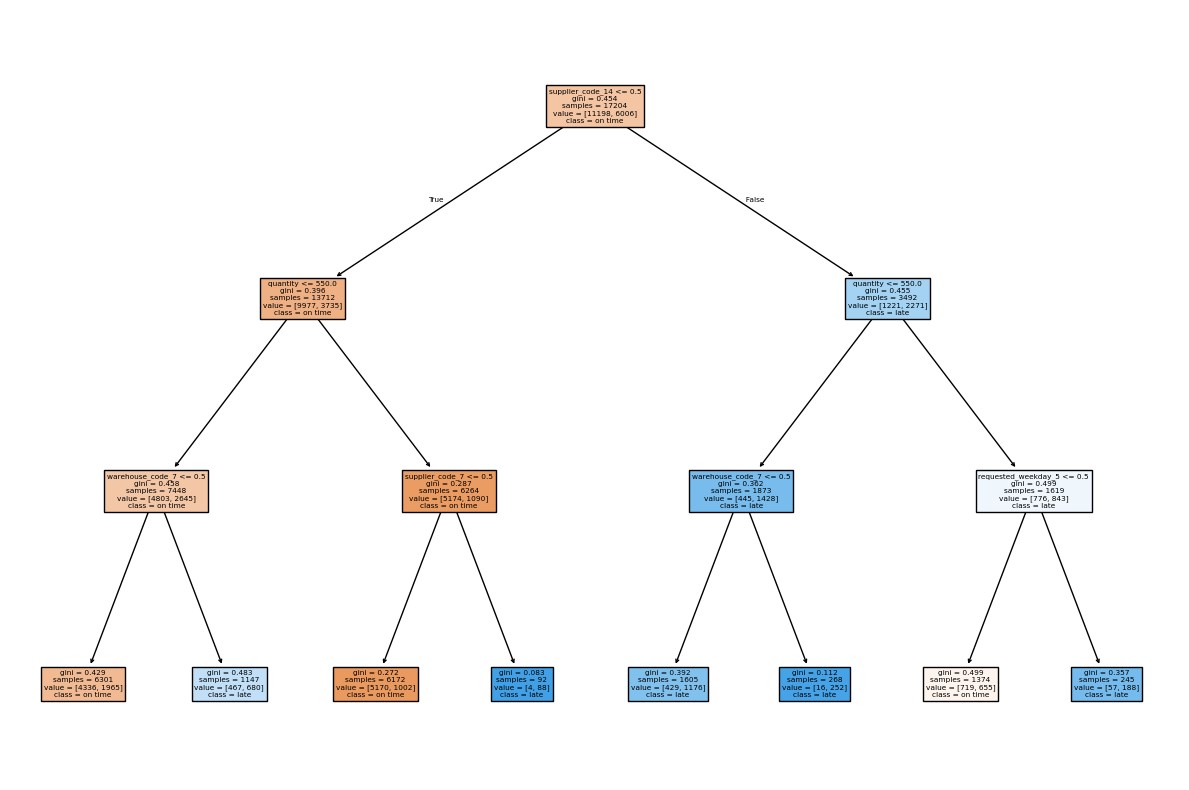

In [24]:
plt.figure(figsize=(12, 8))
plot_tree(
        tree, feature_names=features, 
        class_names=['on time', 'late'], 
        filled=True
        )
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## Model Evaluation

### Calculate Predictions for the tree in the test and training dataset

In [25]:
y_pred_test = tree.predict(X_test)


In [26]:
y_pred_train = tree.predict(X_train)

Total number of transactions predicted late:

In [27]:
y_pred_test.sum()

np.int64(848)

get the confusion matrix for the test dataset 

In [28]:
cm = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

In [29]:
cm

array([[ 612,  904],
       [ 236, 2550]])

In [30]:
cm.T

array([[ 612,  236],
       [ 904, 2550]])

<img src="images/confusion_matrix_structure.png" width="800">

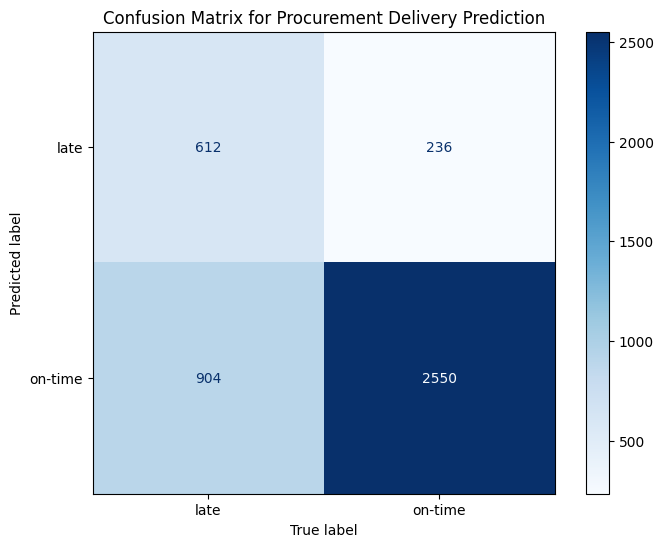

In [31]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm.T, 
    display_labels=['late', 'on-time']
    )

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction')
plt.show()

In [32]:
accuracy_score(y_true=y_train, y_pred=y_pred_train)

0.7329109509416415

In [33]:
precision_score(y_true=y_train, y_pred=y_pred_train)

0.7101578790586833

#### Train a deeper tree

In [34]:
deeper_tree = DecisionTreeClassifier(random_state=random_var, max_depth=100)

In [35]:
deeper_tree.fit(X=X_train, y=y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [36]:
y_pred_train_deeper = deeper_tree.predict(X_train)

In [37]:
y_pred_test_deeper = deeper_tree.predict(X_test)

In [38]:
accuracy_score(y_true=y_train, y_pred=y_pred_train_deeper)

0.9995931178795628

In [39]:
accuracy_score(y_true=y_test, y_pred=y_pred_test_deeper)

0.7480241748024175

### Checking different depth for a treee

In [47]:
for i in range(3, 25):
    _tree = DecisionTreeClassifier(random_state=random_var, max_depth=i)
    _tree.fit(X=X_train, y=y_train)
    _y_pred_train = _tree.predict(X_train)
    _y_pred_test = _tree.predict(X_test)
    print(f'Max depth: {i}, Train Accuracy: {accuracy_score(y_true=y_train, y_pred=_y_pred_train)} - Test Accuracy: {accuracy_score(y_true=y_test, y_pred=_y_pred_test)}')
    

Max depth: 3, Train Accuracy: 0.7329109509416415 - Test Accuracy: 0.7350069735006973
Max depth: 4, Train Accuracy: 0.741106719367589 - Test Accuracy: 0.7438400743840075
Max depth: 5, Train Accuracy: 0.7520925366193908 - Test Accuracy: 0.7508135750813575
Max depth: 6, Train Accuracy: 0.7631364798883981 - Test Accuracy: 0.7591817759181776
Max depth: 7, Train Accuracy: 0.772785398744478 - Test Accuracy: 0.7619711761971176
Max depth: 8, Train Accuracy: 0.7840037200651011 - Test Accuracy: 0.7603440260344027
Max depth: 9, Train Accuracy: 0.7989421064868635 - Test Accuracy: 0.7663877266387726
Max depth: 10, Train Accuracy: 0.8141711229946524 - Test Accuracy: 0.7715016271501627
Max depth: 11, Train Accuracy: 0.8318414322250639 - Test Accuracy: 0.7710367271036727
Max depth: 12, Train Accuracy: 0.8464310625435945 - Test Accuracy: 0.7721989772198977
Max depth: 13, Train Accuracy: 0.8633457335503372 - Test Accuracy: 0.7747559274755927
Max depth: 14, Train Accuracy: 0.8816554289700069 - Test Accura

### Next Model to test Random Forest

Documentation of the Random Forest Function from SKLEARN
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [40]:
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=random_var)